# KNN 

U ovoj svesci primenjuje se KNN regresioni model za predviđanje koncentracije PM2.5. Kod KNN regresije predviđanje se formira na osnovu vrednosti ciljne promenljive kod najsličnijih instanci iz trening skupa.

Posebna pažnja posvećena je izboru optimalnog broja suseda `k`, koji predstavlja jedan od najvažnijih hiperparametara KNN modela.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import metrics
from sklearn import neighbors

# Učitavanje skupa podataka

In [3]:
data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

# Pretprocesiranje podataka

In [4]:
data = data.drop(columns=['No'])
data = data.dropna(subset=['pm2.5'])
data = pd.get_dummies(data, columns=['cbwd'], dtype=int)

Ulazni atributi izdvajaju se u skup `x`, dok ciljnu promenljivu `y` predstavlja koncentracija PM2.5.

In [5]:
x = data.drop(columns=['pm2.5'])
y = data['pm2.5']

In [6]:
x.shape

(41757, 14)

In [7]:
y.shape

(41757,)

In [8]:
feature_names = x.columns
number_of_features = len(feature_names)

## Podela podataka

Podaci se dele na trening, validacioni i test skup. Trening skup koristi se za obučavanje modela, validacioni skup za izbor optimalne vrednosti hiperparametra `k`, dok se test skup koristi za konačnu evaluaciju izabranog modela.

In [9]:
x_train_val, x_test, y_train_val, y_test = model_selection.train_test_split(x, y, test_size=0.33, random_state=7)

In [10]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_train_val, y_train_val, train_size=0.8, random_state=7)

## Standardizacija podataka

KNN model određuje sličnost instanci na osnovu njihovog rastojanja, zbog čega različiti opsezi vrednosti atributa mogu značajno uticati na rezultat modela.

Zbog toga se ulazni podaci standardizuju. Parametri standardizacije određuju se isključivo na trening skupu, a zatim se isti parametri primenjuju na trening, validacioni i test skup kako bi se sprečilo curenje informacija.

In [11]:
scaler = preprocessing.StandardScaler()

In [12]:
scaler.fit(x_train)

StandardScaler()

In [13]:
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

# KNN model sa početnom vrednošću k

Najpre se formira KNN regresioni model sa početno izabranom vrednošću `k = 5`. Performanse ovog modela proveravaju se na validacionom skupu.

In [14]:
knn_model = neighbors.KNeighborsRegressor(n_neighbors=5)

In [15]:
knn_model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [16]:
y_val_pred = knn_model.predict(x_val)

In [17]:
print('R2:', metrics.r2_score(y_val, y_val_pred))
print('MAE:', metrics.mean_absolute_error(y_val, y_val_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_val, y_val_pred)))

R2: 0.5671170458885684
MAE: 38.382022873481056
RMSE: 58.81197933677841


KNN model sa početnom vrednošću `k = 5` na validacionom skupu ostvaruje R² vrednost od približno 0,567, MAE od 38,38 i RMSE od 58,81.

Model objašnjava približno 57% varijabilnosti ciljne promenljive. Kako broj suseda može značajno uticati na performanse KNN modela, u narednom koraku ispituju se različite vrednosti hiperparametra `k` kako bi se pronašla vrednost koja daje bolje rezultate na validacionom skupu.

## Izbor optimalnog broja suseda

U cilju pronalaženja optimalnog broja suseda ispituju se vrednosti `k` od 1 do 20. Za svaku vrednost formira se novi KNN model i računa R² na validacionom skupu.

Za najbolju vrednost `k` bira se ona koja ostvaruje najveću R² vrednost na validacionom skupu.

In [18]:
k_values = range(1, 21)
r2_scores = []

for k in k_values:
    model = neighbors.KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    y_val_pred = model.predict(x_val)
    r2 = metrics.r2_score(y_val, y_val_pred)
    r2_scores.append(r2)

In [19]:
for k, score in zip(k_values, r2_scores):
    print('k = ', k, 'R2 =', score)

k =  1 R2 = 0.563765185057449
k =  2 R2 = 0.6152491881176131
k =  3 R2 = 0.5926046011220623
k =  4 R2 = 0.5777270598536102
k =  5 R2 = 0.5671170458885684
k =  6 R2 = 0.550834214076275
k =  7 R2 = 0.5389285333948175
k =  8 R2 = 0.5268198898672402
k =  9 R2 = 0.5172100438188807
k =  10 R2 = 0.5099349312119211
k =  11 R2 = 0.5013169354916214
k =  12 R2 = 0.4934006602910015
k =  13 R2 = 0.48426411653040646
k =  14 R2 = 0.47789322983622606
k =  15 R2 = 0.4733927357460551
k =  16 R2 = 0.467982859555121
k =  17 R2 = 0.4612893706389186
k =  18 R2 = 0.45544887237473153
k =  19 R2 = 0.4517170164058155
k =  20 R2 = 0.44649838576281864


## Grafički prikaz izbora optimalnog broja suseda

Grafički je prikazana promena R² vrednosti na validacionom skupu u zavisnosti od broja suseda `k`. Na ovaj način može se jasno uočiti koja vrednost `k` daje najbolje performanse modela.

Premala vrednost `k` može dovesti do prevelike osetljivosti modela na pojedinačne instance, dok prevelika vrednost može dovesti do preteranog uprošćavanja predviđanja.

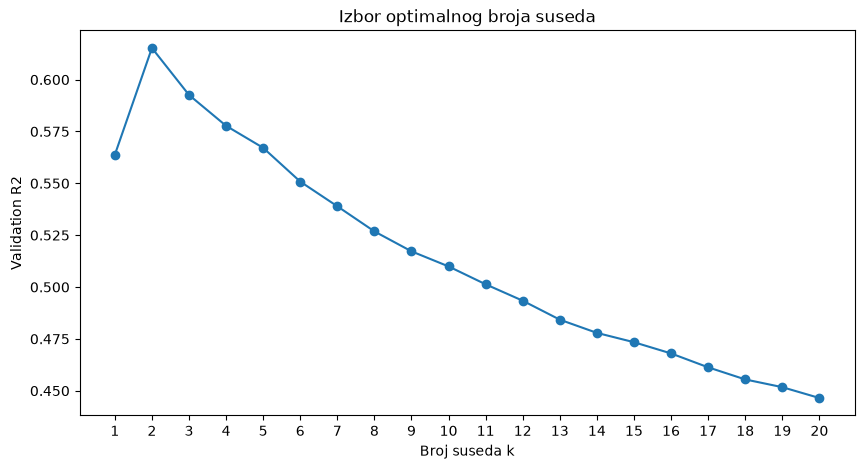

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, r2_scores, marker='o')
plt.xlabel('Broj suseda k')
plt.ylabel('Validation R2')
plt.title('Izbor optimalnog broja suseda')
plt.xticks(k_values)
plt.show()

Na osnovu grafičkog prikaza može se uočiti da se najveća R² vrednost ostvaruje za mali broj suseda. Najbolji rezultat dobijen je za `k = 2`, dok se sa daljim povećanjem broja suseda R² postepeno smanjuje.

Ovakav rezultat pokazuje da za dati skup podataka manji broj suseda omogućava bolje predviđanje koncentracije PM2.5.

In [21]:
best_k = k_values[np.argmax(r2_scores)]

In [22]:
print('Najbolje k:', best_k)
print('Najbolji validation R2:', max(r2_scores))

Najbolje k: 2
Najbolji validation R2: 0.6152491881176131


Najbolji rezultat na validacionom skupu ostvaren je za `k = 2`, pri čemu R² iznosi približno 0,615.

U odnosu na početni model sa `k = 5`, čija je R² vrednost iznosila približno 0,567, izbor optimalnog broja suseda doveo je do poboljšanja performansi modela. Zbog toga se `k = 2` koristi za formiranje konačnog KNN modela.

## Evaluacija najboljeg KNN modela

Nakon izbora optimalnog broja suseda formira se najbolji KNN model i njegove performanse proveravaju se na test skupu, koji nije korišćen prilikom izbora hiperparametra.

In [23]:
best_knn_model = neighbors.KNeighborsRegressor(n_neighbors=best_k)

In [24]:
best_knn_model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [25]:
y_test_pred_knn = best_knn_model.predict(x_test)

In [42]:
print('KNN')

R2 = metrics.r2_score(y_test, y_test_pred_knn)
print('R2:', R2)
MAE = metrics.mean_absolute_error(y_test, y_test_pred_knn)
print('MAE:', MAE)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_knn))
print( 'RMSE:', RMSE)

KNN
R2: 0.6194203019885463
MAE: 33.097169811320754
RMSE: 57.61522184369937


Najbolji KNN model sa `k = 2` na test skupu ostvaruje R² vrednost od približno 0,619, MAE od 33,10 i RMSE od 57,62.

Model objašnjava približno 62% varijabilnosti ciljne promenljive. R² vrednost na test skupu veoma je slična vrednosti dobijenoj na validacionom skupu, što pokazuje da model zadržava slične performanse na podacima koji nisu korišćeni prilikom izbora hiperparametra.

## Evaluacija najboljeg KNN modela na uniji trening i validacionog skupa

In [29]:
x_train_val_scaled = np.vstack([x_train, x_val])
y_train_val        = pd.concat([y_train, y_val])

In [30]:
x_train_val_scaled.shape

(27977, 14)

In [31]:
y_train_val.shape

(27977,)

In [33]:
best_knn_model_train_val = neighbors.KNeighborsRegressor(n_neighbors=best_k)
best_knn_model_train_val.fit(x_train_val_scaled, y_train_val)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [34]:
y_test_pred_knn_train_val = best_knn_model_train_val.predict(x_test)

In [43]:
print('KNN - unija trening i validacije')

R2_union = metrics.r2_score(y_test, y_test_pred_knn_train_val)
print('R2:', R2_union)
MAE_union = metrics.mean_absolute_error(y_test, y_test_pred_knn_train_val)
print('MAE:', MAE_union)
RMSE_union = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_knn_train_val))
print( 'RMSE:', RMSE_union)

KNN - unija trening i validacije
R2: 0.6771087657862582
MAE: 29.484687953555877
RMSE: 53.06920202144586


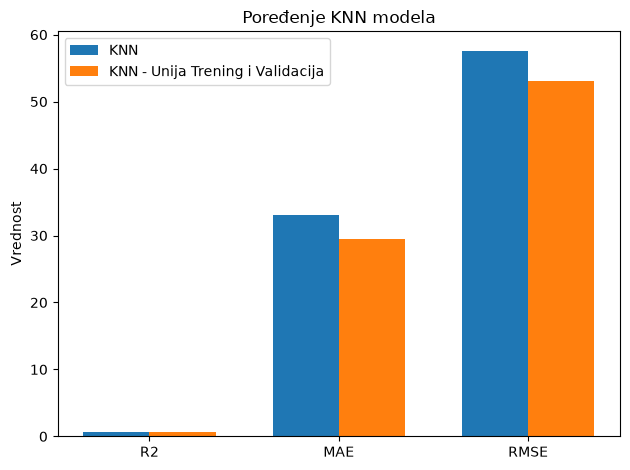

In [45]:
metrike = ['R2', 'MAE', 'RMSE']
KNN = [R2, MAE, RMSE]
KNN_union = [R2_union, MAE_union, RMSE_union]

x = np.arange(len(metrike))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, KNN, width, label='KNN')
ax.bar(x + width/2, KNN_union, width, label='KNN - Unija Trening i Validacija')

ax.set_xticks(x)
ax.set_xticklabels(metrike)
ax.set_ylabel('Vrednost')
ax.set_title('Poređenje KNN modela')

ax.legend()
plt.tight_layout()
plt.show()

Poređenjem dva KNN modela može se uočiti da model treniran na uniji trening i validacionog skupa ostvaruje bolje performanse u sve tri metrike. R² vrednost mu je viša ( približno 0.68 naspram 0.62 ), dok su vrednosti MAE i RMSE niže ( oko 29.5 i 53.1 naspram 33.1 i 57.6 ), što ukazuje na manje greške u predviđanju. Ovakav rezultat pokazuje da KNN model bolje generalizuje kada mu je na raspolaganju veća količina podataka za učenje.

## Čuvanje modela i scaler-a

In [46]:
import joblib

In [47]:
joblib.dump(best_knn_model, "../models/04_KNN.pkl")
joblib.dump(best_knn_model_train_val , "../models/04_KNN_TrainVal")
joblib.dump(scaler, "../models/04_scaler.pkl")

['../models/04_scaler.pkl']